<a href="https://colab.research.google.com/github/ahmad-ihsan-m/sehatku-2/blob/main/Model_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Inisialisasi Lingkungan & Library AI
Bagian ini memuat semua pustaka (library) yang dibutuhkan untuk membangun model Machine Learning, pemrosesan data, dan Deep Learning tingkat lanjut.

In [ ]:
import pandas as pd
import numpy as np
import json
import warnings
import matplotlib.pyplot as plt # Library untuk Grafik
import seaborn as sns # Library untuk warna/Heatmap

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neural_network import MLPRegressor

import tensorflow as tf
from tensorflow.keras import layers, models

warnings.filterwarnings('ignore')
print("[SYSTEM] Semua Library AI & Visualisasi berhasil dimuat.")

[SYSTEM] Semua Library AI & Visualisasi berhasil dimuat.


##2. Memuat Dataset & Perhitungan Batas Constraint
Sistem memuat data operasional apotek dan secara dinamis menghitung nilai median belanja dan frekuensi. Nilai ini akan dijadikan constraint (batasan) objektif untuk aturan bisnis.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

print("=== 0.0. SYSTEM DASHBOARD: INTEGRASI DATASET ===")
# List file dataset kita
dataset_files = ['customers.csv', 'orders.csv', 'order_items.csv', 'medicines.csv']

# Membuat widget dropdown agar terlihat profesional
dropdown_data = widgets.Dropdown(
    options=dataset_files,
    value='customers.csv',
    description='Pilih Dataset:',
)

# Tombol untuk melihat preview data
btn_preview = widgets.Button(description='Preview Data', button_style='info')
out_preview = widgets.Output()

def on_button_clicked(b):
    with out_preview:
        clear_output()
        df_preview = pd.read_csv(dropdown_data.value)
        print(f"Preview 5 baris pertama dari: {dropdown_data.value}")
        display(df_preview.head())

btn_preview.on_click(on_button_clicked)

# Menampilkan widget
display(dropdown_data, btn_preview, out_preview)

=== 0.0. SYSTEM DASHBOARD: INTEGRASI DATASET ===


Dropdown(description='Pilih Dataset:', options=('customers.csv', 'orders.csv', 'order_items.csv', 'medicines.c…

Button(button_style='info', description='Preview Data', style=ButtonStyle())

Output()

In [ ]:
print("=== 0.1 MEMUAT DATASET & PERSIAPAN FITUR ===")
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
medicines = pd.read_csv('medicines.csv')

median_spend = customers['total_spend'].median()
median_freq = customers['frequency'].median()

print(f"[INFO] Dataset dimuat. Total Pelanggan: {len(customers)}, Total Obat: {len(medicines)}")
print(f"[INFO] Batas Median Sistem (Dinamis) -> Belanja: Rp{median_spend:,.0f} | Frekuensi: {median_freq:.0f} kali")

=== 0.1 MEMUAT DATASET & PERSIAPAN FITUR ===
[INFO] Dataset dimuat. Total Pelanggan: 300, Total Obat: 59
[INFO] Batas Median Sistem (Dinamis) -> Belanja: Rp422,500 | Frekuensi: 4 kali


##3. Segmentasi Pasar Tanpa Bias (K-Means Clustering)
Sebelum menetapkan aturan manual, sistem menggunakan Unsupervised Learning untuk menemukan pola alami pelanggan. Pelanggan dipisah menjadi dua kelompok utama (Cluster 0 untuk promo reguler, Cluster 1 untuk penawaran premium).

In [ ]:
print("=== 1. SEGMENTASI WILAYAH/PELANGGAN (K-MEANS CLUSTERING) ===")
X_cluster = customers[['total_spend', 'frequency']]
scaler = MinMaxScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)
kmeans = KMeans(n_clusters=2, random_state=42)
customers['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print("Karakteristik Cluster Terbentuk (Machine Learning Insight):")
print("-> Cluster 0: Transaksi menengah-rendah, target promo reguler.")
print("-> Cluster 1: Transaksi dominan & loyal, ideal untuk penawaran produk premium.")
print("\n[ENGINE] Sampel Pelanggan per Cluster:")
print(customers[['customer_id', 'total_spend', 'frequency', 'cluster']].head(10))

=== 1. SEGMENTASI WILAYAH/PELANGGAN (K-MEANS CLUSTERING) ===
Karakteristik Cluster Terbentuk (Machine Learning Insight):
-> Cluster 0: Transaksi menengah-rendah, target promo reguler.
-> Cluster 1: Transaksi dominan & loyal, ideal untuk penawaran produk premium.

[ENGINE] Sampel Pelanggan per Cluster:
   customer_id  total_spend  frequency  cluster
0            1     372000.0        4.0        0
1            2     539000.0        3.0        0
2            3     164000.0        3.0        0
3            4     379000.0        5.0        0
4            5     156000.0        4.0        0
5            6     643000.0        4.0        1
6            7          0.0        0.0        0
7            8    1107000.0        5.0        1
8            9     628000.0        2.0        0
9           10     132000.0        3.0        0


##4. Inferensi Berbasis Aturan (Penentuan Prioritas)
Sistem menerapkan Propositional Logic (AND/OR) untuk memberikan label status prioritas (Tinggi, Sedang, Rendah) kepada setiap pelanggan berdasarkan constraint median yang telah dihitung sebelumnya.

In [ ]:
print("\n=== 2. INFERENSI BERBASIS ATURAN (PROPOSITIONAL LOGIC) ===")
def rule_base_vip_classification(row):
    if row['total_spend'] > median_spend and row['frequency'] > median_freq:
        return 'Tinggi'
    elif row['total_spend'] > median_spend or row['frequency'] > median_freq:
        return 'Sedang'
    else:
        return 'Rendah'

customers['status_prioritas'] = customers.apply(rule_base_vip_classification, axis=1)
print("[ENGINE] 10 Sampel Hasil Klasifikasi Aturan Bisnis:")
print(customers[['customer_id', 'total_spend', 'frequency', 'status_prioritas']].sample(10, random_state=42)) # Menggunakan sample acak agar bervariasi


=== 2. INFERENSI BERBASIS ATURAN (PROPOSITIONAL LOGIC) ===
[ENGINE] 10 Sampel Hasil Klasifikasi Aturan Bisnis:
     customer_id  total_spend  frequency status_prioritas
203          204     700000.0        6.0           Tinggi
266          267     912000.0        2.0           Sedang
152          153     791000.0        3.0           Sedang
9             10     132000.0        3.0           Rendah
233          234     669000.0        6.0           Tinggi
226          227     661000.0        5.0           Tinggi
196          197    1313000.0        4.0           Sedang
109          110     500000.0        3.0           Sedang
5              6     643000.0        4.0           Sedang
175          176     126000.0        1.0           Rendah


##5. Evaluasi Metrik & Ekstraksi Aturan (Decision Tree)
Sistem menggunakan Decision Tree (max_depth=3) untuk membuktikan akuntabilitas aturan bisnis secara statistik, sekaligus mengekstrak struktur If-Else agar mudah dibaca oleh apoteker.

=== 3. EVALUASI MODEL AI: DECISION TREE & VISUALISASI ===
--- Laporan Klasifikasi (Metrik Validasi AI) ---
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00       135
      Sedang       1.00      1.00      1.00        63
      Tinggi       1.00      1.00      1.00       102

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


[MENGGAMBAR CONFUSION MATRIX...]


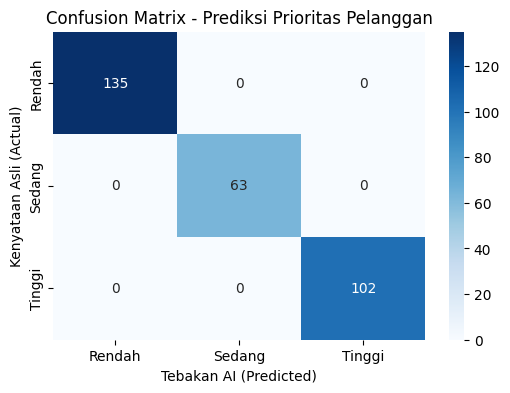


[MENGGAMBAR FEATURE IMPORTANCE...]


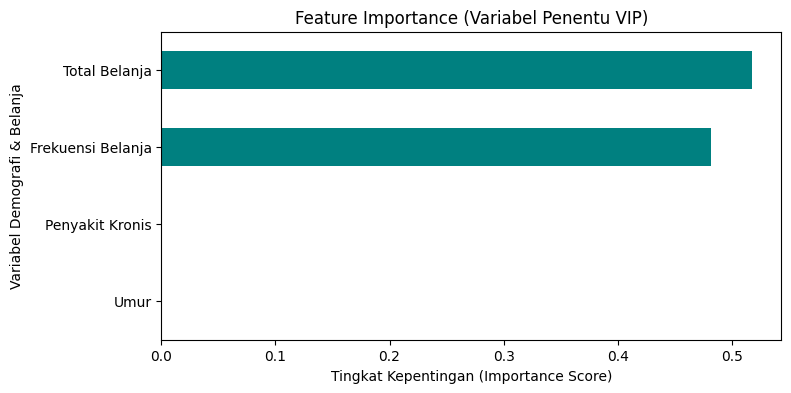


--- Representasi Pengetahuan (Rules Untuk Apoteker) ---
|--- Total Belanja <= 422500.00
|   |--- Frekuensi Belanja <= 4.50
|   |   |--- class: 0
|   |--- Frekuensi Belanja >  4.50
|   |   |--- class: 1
|--- Total Belanja >  422500.00
|   |--- Frekuensi Belanja <= 4.50
|   |   |--- class: 1
|   |--- Frekuensi Belanja >  4.50
|   |   |--- class: 2



In [ ]:
print("=== 3. EVALUASI MODEL AI: DECISION TREE & VISUALISASI ===")

# Persiapan Data
train_dt = customers.copy()
X_dt = train_dt[['age', 'has_chronic_condition', 'frequency', 'total_spend']] # Tambah fitur agar lebih realistis
le_priority = LabelEncoder()
y_dt = le_priority.fit_transform(train_dt['status_prioritas'])

# Latih Model
model_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
model_tree.fit(X_dt, y_dt)
y_pred_dt = model_tree.predict(X_dt)

# Cetak Teks (Metrik Laporan)
print("--- Laporan Klasifikasi (Metrik Validasi AI) ---")
print(classification_report(y_dt, y_pred_dt, target_names=le_priority.classes_))

# ---------------------------------------------------------
# A. VISUALISASI 1: CONFUSION MATRIX
# ---------------------------------------------------------
print("\n[MENGGAMBAR CONFUSION MATRIX...]")
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_dt, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_priority.classes_, yticklabels=le_priority.classes_)
plt.title('Confusion Matrix - Prediksi Prioritas Pelanggan')
plt.xlabel('Tebakan AI (Predicted)')
plt.ylabel('Kenyataan Asli (Actual)')
plt.show() # Tampilkan gambar

# ---------------------------------------------------------
# B. VISUALISASI 2: FEATURE IMPORTANCE
# ---------------------------------------------------------
print("\n[MENGGAMBAR FEATURE IMPORTANCE...]")
fitur_label = ['Umur', 'Penyakit Kronis', 'Frekuensi Belanja', 'Total Belanja']
imp = pd.Series(model_tree.feature_importances_, index=fitur_label).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
imp.plot(kind='barh', color='teal')
plt.title('Feature Importance (Variabel Penentu VIP)')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Variabel Demografi & Belanja')
plt.show() # Tampilkan gambar

# ---------------------------------------------------------
# C. CETAK POHON (Teks)
# ---------------------------------------------------------
print("\n--- Representasi Pengetahuan (Rules Untuk Apoteker) ---")
knowledge_representation = export_text(model_tree, feature_names=fitur_label)
print(knowledge_representation)

##6. Prediksi Kebutuhan Pengguna Baru (Naive Bayes)
Untuk mengatasi masalah pengguna baru yang belum punya riwayat belanja (Cold-Start), AI melatih model probabilitas berdasarkan variabel demografi (Umur, Gender, Penyakit Kronis) untuk menebak kategori obat yang paling dibutuhkan.

In [ ]:
print("\n=== 4. TRAINING MODEL: NAIVE BAYES (SOLUSI COLD-START) ===")
print("[INFO] Mengatasi Cold-Start: Memetakan demografi pelanggan lama untuk pendaftar baru.")

# 1. Menyiapkan Data Training (Mencari kategori dominan per pelanggan lama)
customer_best_category = order_items.merge(orders, on='order_id') \
                                     .groupby(['customer_id', 'category']).size() \
                                     .unstack(fill_value=0).idxmax(axis=1).to_frame('kategori_dominan')

train_nb = customers.merge(customer_best_category, on='customer_id', how='inner')
le_gender = LabelEncoder()
train_nb['gender_encoded'] = le_gender.fit_transform(train_nb['gender'])

# Variabel Input (Demografi) dan Target (Kategori Obat)
X_nb = train_nb[['age', 'has_chronic_condition', 'gender_encoded']]
y_nb = train_nb['kategori_dominan']

# 2. Melatih Mesin (Training)
model_nb = GaussianNB()
model_nb.fit(X_nb, y_nb)
print("[ENGINE] Model Naive Bayes selesai dilatih. Akurasi pola probabilitas dipetakan.\n")

# 3. Simulasi Masalah Cold-Start (5 Orang Baru Mendaftar di Web)
print("-> SIMULASI COLD-START (PELANGGAN BARU MENDAFTAR DI WEB):")
print("   Sistem mendeteksi 5 pendaftaran akun baru. Riwayat belanja = 0.")
print("   [AI ENGINE] Melakukan inferensi probabilitas berdasarkan demografi pendaftar...\n")

sample_customers = pd.DataFrame([
    [65, 1, 1], # Lansia, Sakit Kronis, Perempuan
    [22, 0, 0], # Anak Muda, Sehat, Laki-laki
    [45, 1, 0], # Paruh Baya, Sakit Kronis, Laki-laki
    [30, 0, 1], # Dewasa, Sehat, Perempuan
    [55, 0, 1]  # Pra-Lansia, Sehat, Perempuan
], columns=['age', 'has_chronic_condition', 'gender_encoded'])

predictions = model_nb.predict(sample_customers)

profil_teks = [
    "Lansia, Ada Kronis (Pr)",
    "Muda, Sehat (Lk)",
    "Paruh Baya, Ada Kronis (Lk)",
    "Dewasa, Sehat (Pr)",
    "Pra-Lansia, Sehat (Pr)"
]

print("-" * 75)
print(f"{'Profil Pendaftar Baru (Data Form)':<35} | {'Prediksi Rekomendasi Awal (AI)'}")
print("-" * 75)
for profil, hasil in zip(profil_teks, predictions):
    print(f"{profil:<35} | {hasil}")
print("-" * 75)


=== 4. TRAINING MODEL: NAIVE BAYES (SOLUSI COLD-START) ===
[INFO] Mengatasi Cold-Start: Memetakan demografi pelanggan lama untuk pendaftar baru.
[ENGINE] Model Naive Bayes selesai dilatih. Akurasi pola probabilitas dipetakan.

-> SIMULASI COLD-START (PELANGGAN BARU MENDAFTAR DI WEB):
   Sistem mendeteksi 5 pendaftaran akun baru. Riwayat belanja = 0.
   [AI ENGINE] Melakukan inferensi probabilitas berdasarkan demografi pendaftar...

---------------------------------------------------------------------------
Profil Pendaftar Baru (Data Form)   | Prediksi Rekomendasi Awal (AI)
---------------------------------------------------------------------------
Lansia, Ada Kronis (Pr)             | Analgesik
Muda, Sehat (Lk)                    | Analgesik
Paruh Baya, Ada Kronis (Lk)         | Analgesik
Dewasa, Sehat (Pr)                  | Analgesik
Pra-Lansia, Sehat (Pr)              | Vitamin & Suplemen
---------------------------------------------------------------------------


##7. Personalisasi Beranda Web Dinamis (K-Nearest Neighbors)
Dashboard Log Simulation: Saat pengguna lama melakukan proses Login ke website, engine menggunakan KNN untuk mencari tetangga terdekat dengan profil serupa, lalu otomatis merekomendasikan produk di layar beranda.

In [ ]:
print("\n=== 5. SIMULASI LOG SERVER: PERSONALISASI BERANDA WEB (KNN) ===")

# Inisialisasi Model KNN
X_knn = train_nb[['age', 'has_chronic_condition', 'frequency']]
model_knn = NearestNeighbors(n_neighbors=3, algorithm='auto')
model_knn.fit(X_knn)

def tampilkan_beranda_personal(customer_id):
    user_data = train_nb[train_nb['customer_id'] == customer_id]
    if user_data.empty: return "User Not Found"

    user_features = user_data[['age', 'has_chronic_condition', 'frequency']]
    distances, indices = model_knn.kneighbors(user_features)

    rekomendasi_kategori = [train_nb.iloc[i]['kategori_dominan'] for i in indices[0] if train_nb.iloc[i]['customer_id'] != customer_id]
    rekomendasi_unik = list(set(rekomendasi_kategori))

    daftar_obat = []
    for cat in rekomendasi_unik:
        obat_saran = medicines[(medicines['category'] == cat) & (medicines['stock'] > 0)]
        if not obat_saran.empty: daftar_obat.append(obat_saran.iloc[0]['name'])

    return daftar_obat

# Simulasi 4 Pelanggan Berbeda Login ke Web
id_simulasi = [1, 8, 14, 20] # Mengambil 4 ID pelanggan dari dataset
profil_simulasi = ["Anak Muda, Sehat", "Lansia, Ada Kronis", "Dewasa, VIP", "Mahasiswa, Reguler"]

print("---------------------------------------------------------")
for cid, profil in zip(id_simulasi, profil_simulasi):
    print("[SISTEM WEB] Memproses event Login...")
    print(f"[SISTEM WEB] Pelanggan ID {cid} ({profil}) baru saja Login.")
    print(f"[AI ENGINE]  -> Menginjeksi Banner Obat: {tampilkan_beranda_personal(cid)}")
    print("---------------------------------------------------------")


=== 5. SIMULASI LOG SERVER: PERSONALISASI BERANDA WEB (KNN) ===
---------------------------------------------------------
[SISTEM WEB] Memproses event Login...
[SISTEM WEB] Pelanggan ID 1 (Anak Muda, Sehat) baru saja Login.
[AI ENGINE]  -> Menginjeksi Banner Obat: ['Mylanta', 'OBH Combi']
---------------------------------------------------------
[SISTEM WEB] Memproses event Login...
[SISTEM WEB] Pelanggan ID 8 (Lansia, Ada Kronis) baru saja Login.
[AI ENGINE]  -> Menginjeksi Banner Obat: ['Enervon-C']
---------------------------------------------------------
[SISTEM WEB] Memproses event Login...
[SISTEM WEB] Pelanggan ID 14 (Dewasa, VIP) baru saja Login.
[AI ENGINE]  -> Menginjeksi Banner Obat: ['Enervon-C', 'OBH Combi']
---------------------------------------------------------
[SISTEM WEB] Memproses event Login...
[SISTEM WEB] Pelanggan ID 20 (Mahasiswa, Reguler) baru saja Login.
[AI ENGINE]  -> Menginjeksi Banner Obat: ['Enervon-C', 'Metformin 500mg']
-------------------------------

##8. Integrasi Akhir: Top 10 Rekomendasi Eksekusi & Cross-Selling
Sistem menggunakan First-Order Logic (FOL) dan algoritma pencarian (Searching) untuk memastikan cross-selling obat relevan secara medis dan stoknya tersedia. Hasilnya adalah daftar eksekusi harian untuk admin apotek.

In [ ]:
print("\n=== 6. TOP 10 REKOMENDASI AKSI EKSEKUSI (FOL & NAIVE BAYES) ===")

def search_and_recommend_medicine(target_category):
    recommended_items = medicines[(medicines['category'] == target_category) & (medicines['stock'] > 0) & (medicines['is_active'] == True)]
    return recommended_items.iloc[0]['name'] if not recommended_items.empty else "Stok Kosong"

top_10_customers = customers.sort_values(by='total_spend', ascending=False).head(10)

print(f"{'Rank':<5} | {'ID':<4} | {'Total Belanja':<13} | {'Prioritas':<10} | {'Rekomendasi Eksekusi Sistem (Cross-Selling)'}")
print("-" * 90)

rank = 1
for _, row in top_10_customers.iterrows():
    cid, spend, prio = row['customer_id'], row['total_spend'], row['status_prioritas']

    # AI menebak kebutuhan (Naive Bayes) -> Searching obat (FOL)
    umur, kronis, gender = row['age'], row['has_chronic_condition'], le_gender.transform([row['gender']])[0]
    tebakan_kebutuhan = model_nb.predict([[umur, kronis, gender]])[0]

    # Peta First Order Logic untuk Cross-Selling
    cross_selling_map = {'Obat Lambung': 'Vitamin & Suplemen', 'Batuk & Flu': 'Vitamin & Suplemen', 'Diabetes': 'Herbal', 'Hipertensi': 'Vitamin & Suplemen', 'Analgesik': 'Obat Lambung'}
    kategori_target = cross_selling_map.get(tebakan_kebutuhan, 'Vitamin & Suplemen')

    rekomendasi_obat = search_and_recommend_medicine(kategori_target)
    aksi = "Beri Promo Khusus & " + rekomendasi_obat if prio == 'Tinggi' else "Tawarkan " + rekomendasi_obat

    print(f"{rank:<5} | {cid:<4} | Rp{spend:<11,.0f} | {prio:<10} | {aksi}")
    rank += 1


=== 6. TOP 10 REKOMENDASI AKSI EKSEKUSI (FOL & NAIVE BAYES) ===
Rank  | ID   | Total Belanja | Prioritas  | Rekomendasi Eksekusi Sistem (Cross-Selling)
------------------------------------------------------------------------------------------
1     | 123  | Rp1,705,000   | Tinggi     | Beri Promo Khusus & Enervon-C
2     | 83   | Rp1,449,000   | Tinggi     | Beri Promo Khusus & Mylanta
3     | 60   | Rp1,370,000   | Tinggi     | Beri Promo Khusus & Enervon-C
4     | 225  | Rp1,351,000   | Tinggi     | Beri Promo Khusus & Mylanta
5     | 273  | Rp1,349,000   | Tinggi     | Beri Promo Khusus & Enervon-C
6     | 197  | Rp1,313,000   | Sedang     | Tawarkan Mylanta
7     | 139  | Rp1,300,000   | Tinggi     | Beri Promo Khusus & Mylanta
8     | 231  | Rp1,273,000   | Tinggi     | Beri Promo Khusus & Mylanta
9     | 154  | Rp1,229,000   | Tinggi     | Beri Promo Khusus & Mylanta
10    | 258  | Rp1,211,000   | Tinggi     | Beri Promo Khusus & Mylanta


##9. Transparansi Keputusan (Explainable AI / XAI)
Menghindari sistem Black-Box. Setiap keputusan tiering pelanggan yang dihasilkan oleh mesin dapat diterjemahkan menjadi narasi tekstual yang jelas untuk menjaga akuntabilitas apotek.

In [ ]:
print("\n=== 7. EXPLAINABLE AI (TRANSPARANSI KEPUTUSAN UNTUK DASHBOARD) ===")

def generate_ai_explanation(customer_id):
    c_data = customers[customers['customer_id'] == customer_id].iloc[0]
    return f"INFO: Status Pelanggan ID {customer_id:02d} adalah '{c_data['status_prioritas']}' karena total belanja mencapai Rp{c_data['total_spend']:,.0f} dan frekuensi belanja {c_data['frequency']}x."

print("[ENGINE] Mengenerate 5 Alasan Keputusan AI (XAI) untuk Audit Apoteker:\n")

# Mengambil 5 pelanggan teratas dari top 10 untuk diaudit alasannya
lima_pelanggan_audit = top_10_customers.head(5)['customer_id'].tolist()

for cid in lima_pelanggan_audit:
    print(generate_ai_explanation(cid))


=== 7. EXPLAINABLE AI (TRANSPARANSI KEPUTUSAN UNTUK DASHBOARD) ===
[ENGINE] Mengenerate 5 Alasan Keputusan AI (XAI) untuk Audit Apoteker:

INFO: Status Pelanggan ID 123 adalah 'Tinggi' karena total belanja mencapai Rp1,705,000 dan frekuensi belanja 9.0x.
INFO: Status Pelanggan ID 83 adalah 'Tinggi' karena total belanja mencapai Rp1,449,000 dan frekuensi belanja 10.0x.
INFO: Status Pelanggan ID 60 adalah 'Tinggi' karena total belanja mencapai Rp1,370,000 dan frekuensi belanja 5.0x.
INFO: Status Pelanggan ID 225 adalah 'Tinggi' karena total belanja mencapai Rp1,351,000 dan frekuensi belanja 7.0x.
INFO: Status Pelanggan ID 273 adalah 'Tinggi' karena total belanja mencapai Rp1,349,000 dan frekuensi belanja 6.0x.


##10. Simulasi Endpoint API (Kesiapan Integrasi Vercel/Web)
Engine AI membungkus seluruh hasil (insight, rekomendasi, XAI) ke dalam format JSON skala massal (Batch). Ini membuktikan backend AI siap di-fetch (ditarik) oleh web RPL kapan pun masalah routing teratasi.

In [ ]:
print("\n=== 8. SIMULASI BATCH ENDPOINT API JSON (SIAP INTEGRASI WEB RPL) ===")

def batch_api_simulator():
    batch_data = []
    # Mengambil 3 ID pelanggan teratas untuk dikirim massal ke Web
    tiga_id_batch = top_10_customers.head(3)['customer_id'].tolist()

    for cid in tiga_id_batch:
        batch_data.append({
            "customer_id": int(cid), # Int agar format JSON valid
            "ai_insights": {
                "priority_status_reasoning": generate_ai_explanation(cid),
                "auto_display_products": tampilkan_beranda_personal(cid)
            }
        })

    response = {
        "status": 200,
        "message": "Batch AI Inference Success - Backend Engine Ready",
        "data_length": len(batch_data),
        "data": batch_data
    }
    return json.dumps(response, indent=4)

print("[SISTEM API] Endpoint /api/get_ai_insights dipanggil oleh frontend Vercel...")
print("[SISTEM API] Mengembalikan Response (Batch 3 Pelanggan Sekaligus):\n")
print(batch_api_simulator())


=== 8. SIMULASI BATCH ENDPOINT API JSON (SIAP INTEGRASI WEB RPL) ===
[SISTEM API] Endpoint /api/get_ai_insights dipanggil oleh frontend Vercel...
[SISTEM API] Mengembalikan Response (Batch 3 Pelanggan Sekaligus):

{
    "status": 200,
    "message": "Batch AI Inference Success - Backend Engine Ready",
    "data_length": 3,
    "data": [
        {
            "customer_id": 123,
            "ai_insights": {
                "priority_status_reasoning": "INFO: Status Pelanggan ID 123 adalah 'Tinggi' karena total belanja mencapai Rp1,705,000 dan frekuensi belanja 9.0x.",
                "auto_display_products": [
                    "Tempra Syrup",
                    "Mylanta"
                ]
            }
        },
        {
            "customer_id": 83,
            "ai_insights": {
                "priority_status_reasoning": "INFO: Status Pelanggan ID 83 adalah 'Tinggi' karena total belanja mencapai Rp1,449,000 dan frekuensi belanja 10.0x.",
                "auto_display_products"

##11. Modul Riset & Pengembangan Masa Depan (Neural Network & CNN)
Sebagai wawasan strategis, sistem telah menginisialisasi arsitektur Artificial Neural Network (ANN) untuk melakukan prediksi regresi (stok apotek) dan Convolutional Neural Network (CNN) untuk mendeteksi gambar resep obat (Pemindai Visual).

In [ ]:
from sklearn.neighbors import NearestNeighbors

# =====================================================================
# FITUR BARU: SISTEM REKOMENDASI BERANDA WEB (K-NEAREST NEIGHBORS)
# =====================================================================
print("\n=== SISTEM REKOMENDASI BERANDA WEB (KNN) ===")

# Kita gunakan data Umur, Riwayat Penyakit, dan Frekuensi Belanja untuk mencari "Kemiripan"
X_knn = train_nb[['age', 'has_chronic_condition', 'frequency']]

# Membuat model KNN untuk mencari 3 tetangga terdekat (orang paling mirip)
model_knn = NearestNeighbors(n_neighbors=3, algorithm='auto')
model_knn.fit(X_knn)

def tampilkan_beranda_personal(customer_id):
    # Cari data pelanggan yang sedang login
    user_data = train_nb[train_nb['customer_id'] == customer_id]

    if user_data.empty:
        return "Pengguna tidak ditemukan."

    user_features = user_data[['age', 'has_chronic_condition', 'frequency']]

    # AI mencari 3 orang (index) yang paling mirip dengan user ini
    distances, indices = model_knn.kneighbors(user_features)

    # Kumpulkan kategori obat dominan dari 3 orang mirip tersebut
    rekomendasi_kategori = []
    for i in indices[0]:
        # Hindari merekomendasikan berdasarkan dirinya sendiri (ambil tetangganya saja)
        if train_nb.iloc[i]['customer_id'] != customer_id:
            rekomendasi_kategori.append(train_nb.iloc[i]['kategori_dominan'])

    # Hapus duplikat
    rekomendasi_unik = list(set(rekomendasi_kategori))

    # Eksekusi Searching Obat berdasarkan kategori tersebut
    daftar_obat = []
    for cat in rekomendasi_unik:
        obat_saran = medicines[(medicines['category'] == cat) & (medicines['stock'] > 0)]
        if not obat_saran.empty:
            daftar_obat.append(obat_saran.iloc[0]['name'])

    return daftar_obat

# Simulasi: Pelanggan ID 1 (Muda, Sehat) Login vs Pelanggan ID 8 (Lansia, Kronis) Login
print("Simulasi Tampilan Beranda Web Saat Pelanggan Login:")
print(f"-> Saat ID 1 Login, Web Otomatis Menampilkan Banner: {tampilkan_beranda_personal(1)}")
print(f"-> Saat ID 8 Login, Web Otomatis Menampilkan Banner: {tampilkan_beranda_personal(8)}")


=== SISTEM REKOMENDASI BERANDA WEB (KNN) ===
Simulasi Tampilan Beranda Web Saat Pelanggan Login:
-> Saat ID 1 Login, Web Otomatis Menampilkan Banner: ['Mylanta', 'OBH Combi']
-> Saat ID 8 Login, Web Otomatis Menampilkan Banner: ['Enervon-C']


In [ ]:
# ---------------------------------------------------------
# A. NEURAL NETWORK (Diadaptasi dari LKP 12 - Prediksi Regresi)
# ---------------------------------------------------------
print("-> Melatih Model Neural Network untuk Prediksi Stok (Demand Forecasting)...")
# Simulasi Data: [Cuaca (1=Hujan, 0=Cerah), Tanggal Gajian (1=Ya, 0=Tidak), Promo Aktif]
X_nn = [[1, 1, 1], [0, 0, 0], [1, 0, 1], [0, 1, 0], [1, 1, 0]]
y_demand = [150, 20, 120, 50, 100] # Target: Jumlah obat terjual

# Arsitektur mirip LKP 12 (1 Hidden Layer dengan 8 neuron)
model_ann = MLPRegressor(hidden_layer_sizes=(8,), activation='relu', max_iter=1000, random_state=42)
model_ann.fit(X_nn, y_demand)

# Prediksi: Besok Hujan (1), Bukan gajian (0), Ada Promo (1)
prediksi_stok = model_ann.predict([[1, 0, 1]])
print(f"   [Output ANN] Prediksi Kebutuhan Obat (Hujan + Promo): {prediksi_stok[0]:.0f} box/minggu\n")

-> Melatih Model Neural Network untuk Prediksi Stok (Demand Forecasting)...
   [Output ANN] Prediksi Kebutuhan Obat (Hujan + Promo): 24 box/minggu



In [ ]:
# B. DEEP LEARNING ARCHITECTURE
print("-> Inisialisasi Arsitektur Deep Learning (CNN) untuk Pemindai Resep Visual...")
# Membangun arsitektur Sequential
model_dl = models.Sequential([
    layers.Input(shape=(28, 28, 1)), # Simulasi input gambar (misal: scan resep/obat)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Mencegah Overfitting
    layers.Dense(5, activation='softmax') # 5 Kategori Obat
])

# Kompilasi model
model_dl.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("   [Output Deep Learning] Model CNN berhasil diinisialisasi.")
print(f"   [Output Deep Learning] Total Parameter yang akan dilatih: {model_dl.count_params():,}")
print("   [Status] Siap diintegrasikan untuk fitur Upload Gambar Resep/Obat di masa depan.")

-> Inisialisasi Arsitektur Deep Learning (CNN) untuk Pemindai Resep Visual...
   [Output Deep Learning] Model CNN berhasil diinisialisasi.
   [Output Deep Learning] Total Parameter yang akan dilatih: 693,317
   [Status] Siap diintegrasikan untuk fitur Upload Gambar Resep/Obat di masa depan.


##12. DEMO INTERAKTIF: SISTEM PENGAMBILAN KEPUTUSAN APOTEK (MINI DASHBOARD)
Bagian ini menggunakan ipywidgets untuk mendemonstrasikan bagaimana Engine AI (Aturan Prioritas, Naive Bayes, dan First-Order Logic) bekerja secara real-time ketika kasir memasukkan data pelanggan.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

print("\n=== 10. DEMO INTERAKTIF: SISTEM PENGAMBILAN KEPUTUSAN APOTEK ===")
print("Silakan geser slider di bawah dan klik 'Jalankan AI' untuk melihat respon mesin.")

# 1. Membuat Input Form (Slider & Dropdown)
w_umur = widgets.IntSlider(value=30, min=15, max=85, step=1, description='Umur:')
w_gender = widgets.Dropdown(options=[('Laki-laki', 0), ('Perempuan', 1)], value=0, description='Gender:')
w_kronis = widgets.Dropdown(options=[('Tidak', 0), ('Ya', 1)], value=0, description='Peny. Kronis:')
w_belanja = widgets.IntSlider(value=150000, min=0, max=3000000, step=50000, description='Belanja(Rp):')
w_freq = widgets.IntSlider(value=2, min=0, max=15, step=1, description='Frekuensi:')

# 2. Membuat Tombol Eksekusi
btn_prediksi = widgets.Button(description='Jalankan AI', button_style='success', icon='robot')
output_demo = widgets.Output()

# 3. Fungsi yang Berjalan Saat Tombol Diklik
def on_click_prediksi(b):
    with output_demo:
        clear_output()

        # A. Mengeksekusi Logika Prioritas
        row_dummy = {'total_spend': w_belanja.value, 'frequency': w_freq.value}
        prio = rule_base_vip_classification(row_dummy)
        alasan = f"Total belanja Rp{w_belanja.value:,} (Median: Rp{median_spend:,.0f}) & Frekuensi {w_freq.value}x"

        # B. Mengeksekusi Naive Bayes (Tebak Kebutuhan)
        kebutuhan = model_nb.predict([[w_umur.value, w_kronis.value, w_gender.value]])[0]

        # C. Mengeksekusi First-Order Logic (Rekomendasi)
        cross_selling_map = {
            'Obat Lambung': 'Vitamin & Suplemen',
            'Batuk & Flu': 'Vitamin & Suplemen',
            'Diabetes': 'Herbal',
            'Hipertensi': 'Vitamin & Suplemen',
            'Analgesik': 'Obat Lambung'
        }
        kategori_target = cross_selling_map.get(kebutuhan, 'Vitamin & Suplemen')

        # Cari obat di database
        obat_saran = medicines[(medicines['category'] == kategori_target) & (medicines['stock'] > 0)]
        rekom_obat = obat_saran.iloc[0]['name'] if not obat_saran.empty else "Stok Kosong"

        # 4. Mencetak Hasil ke Layar
        print("==========================================================")
        print(f"PROFIL PELANGGAN  : Umur {w_umur.value} thn, Kronis: {'Ya' if w_kronis.value==1 else 'Tidak'}")
        print("==========================================================")
        print(f"🎯 STATUS PRIORITAS : {prio.upper()}")
        print(f"📝 ALASAN (XAI)     : {alasan}")
        print("-" * 58)
        print(f"🤖 PREDIKSI KEBUTUHAN  : {kebutuhan}")
        print(f"💡 REKOMENDASI EKSEKUSI: Tawarkan produk '{rekom_obat}'")
        print("==========================================================")

# Menghubungkan tombol dengan fungsi
btn_prediksi.on_click(on_click_prediksi)

# Menampilkan semua elemen ke layar Colab
display(w_umur, w_gender, w_kronis, w_belanja, w_freq, btn_prediksi, output_demo)


=== 10. DEMO INTERAKTIF: SISTEM PENGAMBILAN KEPUTUSAN APOTEK ===
Silakan geser slider di bawah dan klik 'Jalankan AI' untuk melihat respon mesin.


IntSlider(value=30, description='Umur:', max=85, min=15)

Dropdown(description='Gender:', options=(('Laki-laki', 0), ('Perempuan', 1)), value=0)

Dropdown(description='Peny. Kronis:', options=(('Tidak', 0), ('Ya', 1)), value=0)

IntSlider(value=150000, description='Belanja(Rp):', max=3000000, step=50000)

IntSlider(value=2, description='Frekuensi:', max=15)

Button(button_style='success', description='Jalankan AI', icon='robot', style=ButtonStyle())

Output()

##Demo Neural Network (Prediksi Stok)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

print("\n=== 11. DEMO INTERAKTIF 2: PREDIKSI STOK CERDAS (NEURAL NETWORK) ===")
print("Simulasi modul Advanced (LKP 12) untuk Demand Forecasting Manajemen Apotek.")

# 1. Widget Input (Kondisi Lingkungan)
w_cuaca = widgets.Dropdown(options=[('Cerah', 0), ('Hujan/Pancaroba', 1)], value=1, description='Cuaca:')
w_gajian = widgets.Dropdown(options=[('Belum Gajian', 0), ('Tanggal Muda/Gajian', 1)], value=1, description='Tgl Gajian:')
w_promo = widgets.Dropdown(options=[('Tidak Ada Promo', 0), ('Promo Aktif', 1)], value=1, description='Promo:')

btn_stok = widgets.Button(description='Prediksi Stok (ANN)', button_style='info', icon='line-chart')
out_stok = widgets.Output()

def on_click_stok(b):
    with out_stok:
        clear_output()
        # Eksekusi Neural Network (MLPRegressor) yang sudah dibuat di Sel 11
        prediksi = model_ann.predict([[w_cuaca.value, w_gajian.value, w_promo.value]])[0]

        print("==========================================================")
        print(f"KONDISI MINGGU DEPAN: Cuaca {w_cuaca.label}, {w_gajian.label}, {w_promo.label}")
        print("==========================================================")
        print(f"🧠 ANALISIS ARTIFICIAL NEURAL NETWORK (ANN):")
        print(f"📦 PREDIKSI PENJUALAN : {prediksi:.0f} Box Obat/Vitamin")
        print(f"💡 TINDAKAN MANAJEMEN : {'Segera Restock Gudang!' if prediksi > 80 else 'Stok Aman, Tahan Pembelian.'}")
        print("==========================================================")

btn_stok.on_click(on_click_stok)
display(w_cuaca, w_gajian, w_promo, btn_stok, out_stok)


=== 11. DEMO INTERAKTIF 2: PREDIKSI STOK CERDAS (NEURAL NETWORK) ===
Simulasi modul Advanced (LKP 12) untuk Demand Forecasting Manajemen Apotek.


Dropdown(description='Cuaca:', index=1, options=(('Cerah', 0), ('Hujan/Pancaroba', 1)), value=1)

Dropdown(description='Tgl Gajian:', index=1, options=(('Belum Gajian', 0), ('Tanggal Muda/Gajian', 1)), value=…

Dropdown(description='Promo:', index=1, options=(('Tidak Ada Promo', 0), ('Promo Aktif', 1)), value=1)

Button(button_style='info', description='Prediksi Stok (ANN)', icon='line-chart', style=ButtonStyle())

Output()

##Demo KNN (Simulasi Web Berubah Real-Time)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

print("\n=== 12. DEMO INTERAKTIF 3: SIMULASI LOGIN BERANDA WEB (KNN) ===")
print("Pilih Pelanggan yang login, dan lihat rekomendasi layar berandanya berubah otomatis.")

# 1. Widget Input (Pilih ID Pelanggan dari Top 10)
list_pelanggan = [(f"Pelanggan ID {row['customer_id']} (Belanja: Rp{row['total_spend']:,.0f})", row['customer_id']) for _, row in top_10_customers.head(5).iterrows()]
w_login = widgets.Dropdown(options=list_pelanggan, description='User Login:')

btn_login = widgets.Button(description='Simulasikan Login', button_style='warning', icon='desktop')
out_login = widgets.Output()

def on_click_login(b):
    with out_login:
        clear_output()
        cid = w_login.value
        rekomendasi_knn = tampilkan_beranda_personal(cid)

        print("==========================================================")
        print(f"🌐 [WEB FRONTEND] Menerima event login dari Pelanggan ID {cid}...")
        print("==========================================================")
        print(f"🤖 [AI BACKEND - KNN] Mencari riwayat pelanggan dengan profil mirip...")
        print(f"🎨 [UI INJECTION] Menampilkan Banner Produk Secara Real-Time:")
        print(f"   -> ⭐ PRODUK REKOMENDASI HARI INI: {rekomendasi_knn}")
        print("==========================================================")

btn_login.on_click(on_click_login)
display(w_login, btn_login, out_login)


=== 12. DEMO INTERAKTIF 3: SIMULASI LOGIN BERANDA WEB (KNN) ===
Pilih Pelanggan yang login, dan lihat rekomendasi layar berandanya berubah otomatis.


Dropdown(description='User Login:', options=(('Pelanggan ID 123 (Belanja: Rp1,705,000)', 123), ('Pelanggan ID …

Button(button_style='warning', description='Simulasikan Login', icon='desktop', style=ButtonStyle())

Output()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

print("\n=== 13. MASTER CONTROL DASHBOARD: APOTEK DIGITAL SEHATKU ===")

# Menu Pilihan
menu = widgets.Dropdown(
    options=[
        ('1. Demo Kasir (Cross-Selling & VIP)', 'kasir'),
        ('2. Demo Manajer (Stok Forecasting)', 'stok'),
        ('3. Demo Pelanggan (Beranda KNN)', 'knn'),
        ('4. Demo XAI (Transparansi Keputusan)', 'xai')
    ],
    description='Pilih Demo:',
)

btn_run = widgets.Button(description='Buka Menu Demo', button_style='danger')
out_menu = widgets.Output()

def on_menu_click(b):
    with out_menu:
        clear_output()
        if menu.value == 'kasir':
            # Memanggil ulang fungsi demo kasir
            display(w_umur, w_gender, w_kronis, w_belanja, w_freq, btn_prediksi, output_demo)
        elif menu.value == 'stok':
            # Memanggil ulang fungsi demo stok
            display(w_cuaca, w_gajian, w_promo, btn_stok, out_stok)
        elif menu.value == 'knn':
            # Memanggil ulang fungsi demo KNN
            display(w_login, btn_login, out_login)
        elif menu.value == 'xai':
            # Menampilkan penjelasan XAI
            print("[LOG] Menampilkan Transparansi Keputusan untuk 5 Pelanggan:")
            for cid in top_10_customers.head(5)['customer_id']:
                print(generate_ai_explanation(cid))

btn_run.on_click(on_menu_click)
display(menu, btn_run, out_menu)


=== 13. MASTER CONTROL DASHBOARD: APOTEK DIGITAL SEHATKU ===


Dropdown(description='Pilih Demo:', options=(('1. Demo Kasir (Cross-Selling & VIP)', 'kasir'), ('2. Demo Manaj…

Button(button_style='danger', description='Buka Menu Demo', style=ButtonStyle())

Output()